# EAAI Ablation Experiments for the Hybrid CNN-SVM Bearing-Fault Model

This notebook runs the heavier experiments suggested for an Engineering Applications of Artificial Intelligence submission:

- SVM classifiers trained on features extracted from different CNN layers.
- Linear versus RBF SVM kernels.
- Raw features versus standardized features.
- Paired statistical tests across repeated runs.

The notebook saves all intermediate outputs needed for later analysis in `ablation_outputs/`.
It is intentionally more expensive than the article's current result-regeneration script.



In [1]:
from __future__ import annotations

import importlib
import subprocess
import sys

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "tensorflow": "tensorflow",
    "matplotlib": "matplotlib",
    "tqdm": "tqdm",
}

missing = []
for import_name, package_name in REQUIRED_PACKAGES.items():
    if importlib.util.find_spec(import_name) is None:
        missing.append(package_name)

if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All required packages are already installed.")

# Re-check imports after optional installation.
for import_name in REQUIRED_PACKAGES:
    importlib.import_module(import_name)
print("Dependency check complete.")



Installing missing packages: ['tqdm']
Dependency check complete.


In [2]:
import json
import os
import random
import time
import zipfile
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from scipy.io import loadmat
from scipy.stats import kurtosis, skew, shapiro, ttest_rel, wilcoxon
from sklearn import metrics
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Input, MaxPooling1D
from tensorflow.keras.models import Model
from tqdm.auto import tqdm

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("scikit-learn:", importlib.import_module("sklearn").__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as exc:
        print("Could not set memory growth for", gpu, exc)



c:\Users\lamar\anaconda3\envs\tf_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.9.25 (main, Nov  3 2025, 22:44:01) [MSC v.1929 64 bit (AMD64)]
TensorFlow: 2.10.0
NumPy: 1.26.4
Pandas: 2.3.3
scikit-learn: 1.6.1
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Experiment Configuration

Use `SMOKE_TEST = True` only to verify that the notebook runs on a new computer.
For the real experiment, keep `SMOKE_TEST = False`.



In [3]:
SMOKE_TEST = False

N_RUNS = 46
EPOCHS = 100
BATCH_SIZE = 2000
PREDICT_BATCH_SIZE = 2048
BASE_SEED = 1000

SVM_KERNELS = ["linear", "rbf"]
NORMALIZATION_MODES = ["raw", "standardized"]

# Expensive option. Early CNN layers have high-dimensional outputs, especially pool1.
LAYER_NAMES = ["pool1", "pool2", "pool3", "conv4", "conv5", "flatten", "dense32"]

# Set to a number such as 12000 to skip RBF on very high-dimensional features.
# Keep as None for the complete expensive grid.
SKIP_RBF_IF_FEATURE_DIM_EXCEEDS = None

SAVE_FEATURE_ARRAYS = False
SAVE_TRAINED_MODELS = False

if SMOKE_TEST:
    N_RUNS = 1
    EPOCHS = 1
    LAYER_NAMES = ["pool3", "dense32"]
    SVM_KERNELS = ["linear"]
    NORMALIZATION_MODES = ["standardized"]

print(
    json.dumps(
        {
            "SMOKE_TEST": SMOKE_TEST,
            "N_RUNS": N_RUNS,
            "EPOCHS": EPOCHS,
            "BATCH_SIZE": BATCH_SIZE,
            "LAYER_NAMES": LAYER_NAMES,
            "SVM_KERNELS": SVM_KERNELS,
            "NORMALIZATION_MODES": NORMALIZATION_MODES,
        },
        indent=2,
    )
)



{
  "SMOKE_TEST": false,
  "N_RUNS": 46,
  "EPOCHS": 100,
  "BATCH_SIZE": 2000,
  "LAYER_NAMES": [
    "pool1",
    "pool2",
    "pool3",
    "conv4",
    "conv5",
    "flatten",
    "dense32"
  ],
  "SVM_KERNELS": [
    "linear",
    "rbf"
  ],
  "NORMALIZATION_MODES": [
    "raw",
    "standardized"
  ]
}


In [4]:
NOTEBOOK_DIR = Path.cwd().resolve()
DATASET_ZIP_NAME = "dataset-20210905T162441Z-001.zip"
REQUIRED_MAT_FILES = [
    "B007_0.mat",
    "B007_1.mat",
    "B007_2.mat",
    "B007_3.mat",
    "B014_0.mat",
    "B014_1.mat",
    "B014_2.mat",
    "B014_3.mat",
    "B021_0.mat",
    "B021_1.mat",
    "B021_2.mat",
    "B021_3.mat",
    "IR007_0.mat",
    "IR007_1.mat",
    "IR007_2.mat",
    "IR007_3.mat",
    "IR014_0.mat",
    "IR014_1.mat",
    "IR014_2.mat",
    "IR014_3.mat",
    "IR021_0.mat",
    "IR021_1.mat",
    "IR021_2.mat",
    "IR021_3.mat",
    "OR007@6_0.mat",
    "OR007@6_1.mat",
    "OR007@6_2.mat",
    "OR007@6_3.mat",
    "OR014@6_0.mat",
    "OR014@6_1.mat",
    "OR014@6_2.mat",
    "OR014@6_3.mat",
    "OR021@6_0.mat",
    "OR021@6_1.mat",
    "OR021@6_2.mat",
    "OR021@6_3.mat",
    "normal_0.mat",
    "normal_1.mat",
    "normal_2.mat",
    "normal_3.mat",
]


def find_dir_with_required_mats(search_roots: list[Path]) -> Path | None:
    seen: set[Path] = set()
    for root in search_roots:
        root = root.resolve()
        if not root.exists() or root in seen:
            continue
        seen.add(root)
        candidates = [root]
        candidates.extend(path for path in root.rglob("*") if path.is_dir())
        for candidate in candidates:
            if all((candidate / name).exists() for name in REQUIRED_MAT_FILES):
                return candidate.resolve()
    return None


def locate_or_extract_dataset() -> Path:
    search_roots = [
        NOTEBOOK_DIR,
        NOTEBOOK_DIR / "dataset",
        NOTEBOOK_DIR / "Notebook" / "dataset",
        NOTEBOOK_DIR.parent,
        NOTEBOOK_DIR.parent / "Notebook" / "dataset",
        NOTEBOOK_DIR.parents[1] / "Notebook" / "dataset" if len(NOTEBOOK_DIR.parents) > 1 else NOTEBOOK_DIR,
    ]
    existing = find_dir_with_required_mats(search_roots)
    if existing is not None:
        return existing

    zip_candidates = [
        NOTEBOOK_DIR / DATASET_ZIP_NAME,
        NOTEBOOK_DIR.parent / DATASET_ZIP_NAME,
        NOTEBOOK_DIR / "dataset.zip",
    ]
    zip_candidates.extend(NOTEBOOK_DIR.glob("*.zip"))
    zip_candidates = [path for path in zip_candidates if path.exists()]
    if not zip_candidates:
        raise FileNotFoundError(
            "Could not find the dataset .mat files or a dataset zip. "
            f"Put {DATASET_ZIP_NAME} in the same folder as this notebook, or unzip the .mat files into a local dataset/ folder."
        )

    zip_path = zip_candidates[0].resolve()
    extract_dir = NOTEBOOK_DIR / "dataset_extracted"
    extract_dir.mkdir(parents=True, exist_ok=True)
    print(f"Extracting dataset zip: {zip_path}")
    print(f"Extraction folder: {extract_dir}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

    extracted = find_dir_with_required_mats([extract_dir])
    if extracted is None:
        mat_count = len(list(extract_dir.rglob("*.mat")))
        raise FileNotFoundError(
            f"Dataset zip was extracted, but the expected .mat files were not found together in one folder. "
            f"Found {mat_count} .mat files under {extract_dir}."
        )
    return extracted


PAPER_DIR = NOTEBOOK_DIR
DATASET_DIR = locate_or_extract_dataset()
OUTPUT_DIR = NOTEBOOK_DIR / "ablation_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for sub in ["histories", "predictions", "confusion_matrices", "features", "models", "figures"]:
    (OUTPUT_DIR / sub).mkdir(parents=True, exist_ok=True)

print("Working directory:", NOTEBOOK_DIR)
print("Dataset directory:", DATASET_DIR)
print("Output directory:", OUTPUT_DIR)



Extracting dataset zip: C:\Users\lamar\Desktop\Vinicius\EAAI Tests\dataset-20210905T162441Z-001.zip
Extraction folder: C:\Users\lamar\Desktop\Vinicius\EAAI Tests\dataset_extracted
Working directory: C:\Users\lamar\Desktop\Vinicius\EAAI Tests
Dataset directory: C:\Users\lamar\Desktop\Vinicius\EAAI Tests\dataset_extracted\dataset
Output directory: C:\Users\lamar\Desktop\Vinicius\EAAI Tests\ablation_outputs


## Data Loading

This reproduces the same CWRU file grouping and windowing strategy used in the article.



In [5]:
FAULT_FILES = [
    "B007_0", "B007_1", "B007_2", "B007_3",
    "B014_0", "B014_1", "B014_2", "B014_3",
    "B021_0", "B021_1", "B021_2", "B021_3",
    "IR007_0", "IR007_1", "IR007_2", "IR007_3",
    "IR014_0", "IR014_1", "IR014_2", "IR014_3",
    "IR021_0", "IR021_1", "IR021_2", "IR021_3",
    "OR007@6_0", "OR007@6_1", "OR007@6_2", "OR007@6_3",
    "OR014@6_0", "OR014@6_1", "OR014@6_2", "OR014@6_3",
    "OR021@6_0", "OR021@6_1", "OR021@6_2", "OR021@6_3",
]
NORMAL_FILES = ["normal_0", "normal_1", "normal_2", "normal_3"]
CLASS_LABELS = ["B007", "B014", "B021", "IR007", "IR014", "IR021", "OR007", "OR014", "OR021", "Normal"]


def load_drive_end_signal(stem: str) -> np.ndarray:
    mat = loadmat(DATASET_DIR / f"{stem}.mat")
    keys = [key for key in mat if key.endswith("_DE_time")]
    if not keys:
        raise KeyError(f"No drive-end signal found in {stem}.mat")
    return np.asarray(mat[keys[0]], dtype=np.float32).reshape(-1, 1)


def build_windows(seed: int) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    files = FAULT_FILES + NORMAL_FILES
    windows = {}
    for idx, stem in enumerate(files):
        signal = load_drive_end_signal(stem)
        count = 200 if idx < 36 else (400 if idx == 36 else 800)
        windows[stem] = signal[: count * 604].reshape(count, 604, 1)

    rng = np.random.RandomState(seed)
    order_200 = rng.permutation(200)
    train_parts = []
    test_parts = []
    for stem in FAULT_FILES:
        train_parts.append(windows[stem][order_200][:160])
        test_parts.append(windows[stem][order_200][-40:])

    order_400 = rng.permutation(400)
    train_parts.append(windows["normal_0"][order_400][: 2 * 160])
    test_parts.append(windows["normal_0"][order_400][2 * (-40) :])

    order_800 = rng.permutation(800)
    for stem in ["normal_1", "normal_2", "normal_3"]:
        train_parts.append(windows[stem][order_800][: 4 * 160])
        test_parts.append(windows[stem][order_800][4 * (-40) :])

    x_train = np.concatenate(train_parts, axis=0)
    x_test = np.concatenate(test_parts, axis=0)
    y_train = np.concatenate([np.full(4 * 160, k) for k in range(9)] + [np.full(14 * 160, 9)]).astype(np.int64)
    y_test = np.concatenate([np.full(4 * 40, k) for k in range(9)] + [np.full(14 * 40, 9)]).astype(np.int64)
    return x_train, x_test, y_train, y_test


def statistical_features(signals: np.ndarray) -> np.ndarray:
    x = signals.reshape(signals.shape[0], -1)
    rms = np.sqrt(np.mean(x**2, axis=1))
    max_value = np.max(x, axis=1)
    crest = max_value / rms
    skewness = skew(x, axis=1, bias=True)
    kurt = kurtosis(x, axis=1, bias=True)
    return np.column_stack([rms, max_value, crest, skewness, kurt])


sample_x_train, sample_x_test, sample_y_train, sample_y_test = build_windows(BASE_SEED)
print("Train shape:", sample_x_train.shape, sample_y_train.shape)
print("Test shape:", sample_x_test.shape, sample_y_test.shape)
print("Class counts train:", dict(zip(CLASS_LABELS, np.bincount(sample_y_train))))
print("Class counts test:", dict(zip(CLASS_LABELS, np.bincount(sample_y_test))))
del sample_x_train, sample_x_test, sample_y_train, sample_y_test



Train shape: (8000, 604, 1) (8000,)
Test shape: (2000, 604, 1) (2000,)
Class counts train: {'B007': 640, 'B014': 640, 'B021': 640, 'IR007': 640, 'IR014': 640, 'IR021': 640, 'OR007': 640, 'OR014': 640, 'OR021': 640, 'Normal': 2240}
Class counts test: {'B007': 160, 'B014': 160, 'B021': 160, 'IR007': 160, 'IR014': 160, 'IR021': 160, 'OR007': 160, 'OR014': 160, 'OR021': 160, 'Normal': 560}


## Model and Feature Extraction



In [6]:
def set_all_seeds(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)


def build_named_cnn(input_length: int = 604) -> Model:
    input_signal = Input(shape=(input_length, 1), name="vibration_window")
    x = Conv1D(64, kernel_size=250, strides=2, padding="same", activation="relu", name="conv1")(input_signal)
    x = MaxPooling1D(pool_size=2, name="pool1")(x)
    x = Conv1D(48, kernel_size=20, activation="relu", name="conv2")(x)
    x = MaxPooling1D(pool_size=2, name="pool2")(x)
    x = Conv1D(36, kernel_size=16, activation="relu", name="conv3")(x)
    x = MaxPooling1D(pool_size=2, name="pool3")(x)
    x = Conv1D(24, kernel_size=16, activation="relu", name="conv4")(x)
    x = Conv1D(8, kernel_size=7, activation="relu", name="conv5")(x)
    encoded = Flatten(name="flatten")(x)
    dense = Dense(32, activation="sigmoid", name="dense32")(encoded)
    output = Dense(10, activation="softmax", name="softmax")(dense)
    model = Model(input_signal, output, name="cnn_classifier")
    model.compile(loss="sparse_categorical_crossentropy", optimizer="Adam", metrics=["accuracy"])
    return model


def extract_layer_features(model: Model, layer_name: str, x_train: np.ndarray, x_test: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    extractor = Model(model.input, model.get_layer(layer_name).output)
    train = extractor.predict(x_train, batch_size=PREDICT_BATCH_SIZE, verbose=0)
    test = extractor.predict(x_test, batch_size=PREDICT_BATCH_SIZE, verbose=0)
    train = train.reshape(train.shape[0], -1)
    test = test.reshape(test.shape[0], -1)
    return train, test


model_preview = build_named_cnn()
model_preview.summary()
print("Available layers:", [layer.name for layer in model_preview.layers])
del model_preview



Model: "cnn_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vibration_window (InputLaye  [(None, 604, 1)]         0         
 r)                                                              
                                                                 
 conv1 (Conv1D)              (None, 302, 64)           16064     
                                                                 
 pool1 (MaxPooling1D)        (None, 151, 64)           0         
                                                                 
 conv2 (Conv1D)              (None, 132, 48)           61488     
                                                                 
 pool2 (MaxPooling1D)        (None, 66, 48)            0         
                                                                 
 conv3 (Conv1D)              (None, 51, 36)            27684     
                                                    

## Incremental Output Helpers



In [ ]:
@dataclass
class AccuracyRow:
    run: int
    seed: int
    model_id: str
    source: str
    layer: str
    kernel: str
    normalization: str
    feature_dim: int
    train_accuracy_percent: float
    test_accuracy_percent: float
    fit_seconds: float
    predict_seconds: float


RESULTS_PATH = OUTPUT_DIR / "ablation_accuracy_long.csv"
METADATA_PATH = OUTPUT_DIR / "ablation_metadata.json"


def write_incremental_results(rows: list[AccuracyRow]) -> None:
    frame = pd.DataFrame([asdict(row) for row in rows])
    frame.to_csv(RESULTS_PATH, index=False)


def safe_model_id(source: str, layer: str, kernel: str, normalization: str) -> str:
    parts = [source, layer, kernel, normalization]
    return "__".join(str(part).replace(" ", "_").replace("/", "_") for part in parts)


def save_predictions_and_confusion(
    run: int,
    model_id: str,
    y_true: np.ndarray,
    y_pred: np.ndarray,
) -> None:
    pred_path = OUTPUT_DIR / "predictions" / f"run_{run:03d}__{model_id}.csv"
    pd.DataFrame({"true_label": y_true, "predicted_label": y_pred}).to_csv(pred_path, index=False)

    cm = metrics.confusion_matrix(y_true, y_pred, labels=np.arange(len(CLASS_LABELS)))
    cm_frame = pd.DataFrame(cm, index=CLASS_LABELS, columns=CLASS_LABELS)
    cm_frame.index.name = "true_class"
    cm_frame.to_csv(OUTPUT_DIR / "confusion_matrices" / f"run_{run:03d}__{model_id}.csv")


metadata = {
    "created_by": "eai_ablation_experiments.ipynb",
    "working_dir": str(NOTEBOOK_DIR),
    "dataset_dir": str(DATASET_DIR),
    "output_dir": str(OUTPUT_DIR),
    "n_runs": N_RUNS,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "predict_batch_size": PREDICT_BATCH_SIZE,
    "base_seed": BASE_SEED,
    "layer_names": LAYER_NAMES,
    "svm_kernels": SVM_KERNELS,
    "normalization_modes": NORMALIZATION_MODES,
    "skip_rbf_if_feature_dim_exceeds": SKIP_RBF_IF_FEATURE_DIM_EXCEEDS,
    "save_feature_arrays": SAVE_FEATURE_ARRAYS,
    "save_trained_models": SAVE_TRAINED_MODELS,
    "class_labels": CLASS_LABELS,
}
METADATA_PATH.write_text(json.dumps(metadata, indent=2), encoding="utf-8")
print("Wrote metadata:", METADATA_PATH)



## Main Experiment

This is the expensive cell. It trains `N_RUNS` CNNs and evaluates each requested layer/SVM/normalization combination.
Results are saved after every run, so a partial run can still be analyzed.



In [8]:
all_rows: list[AccuracyRow] = []
if RESULTS_PATH.exists():
    previous = pd.read_csv(RESULTS_PATH)
    all_rows = [AccuracyRow(**row) for row in previous.to_dict(orient="records")]
    print(f"Loaded {len(all_rows)} existing result rows from {RESULTS_PATH}")

completed_runs = sorted({int(row.run) for row in all_rows})
print("Completed runs:", completed_runs)

for run in tqdm(range(1, N_RUNS + 1), desc="ablation runs"):
    if run in completed_runs:
        continue

    seed = BASE_SEED + run - 1
    set_all_seeds(seed)
    x_train, x_test, y_train, y_test = build_windows(seed)

    model = build_named_cnn(input_length=x_train.shape[1])
    start = time.perf_counter()
    history = model.fit(x_train, y_train, batch_size=BATCH_SIZE, epochs=EPOCHS, verbose=2)
    cnn_fit_seconds = time.perf_counter() - start

    history_frame = pd.DataFrame(history.history)
    history_frame.insert(0, "epoch", np.arange(1, len(history_frame) + 1))
    history_frame.to_csv(OUTPUT_DIR / "histories" / f"run_{run:03d}__cnn_training_history.csv", index=False)

    start = time.perf_counter()
    train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    pred_prob = model.predict(x_test, batch_size=PREDICT_BATCH_SIZE, verbose=0)
    pred_cnn = np.argmax(pred_prob, axis=1)
    predict_seconds = time.perf_counter() - start
    model_id = "cnn_softmax"
    save_predictions_and_confusion(run, model_id, y_test, pred_cnn)
    all_rows.append(
        AccuracyRow(
            run=run,
            seed=seed,
            model_id=model_id,
            source="cnn_softmax",
            layer="softmax",
            kernel="softmax",
            normalization="not_applicable",
            feature_dim=10,
            train_accuracy_percent=float(train_acc * 100),
            test_accuracy_percent=float(test_acc * 100),
            fit_seconds=float(cnn_fit_seconds),
            predict_seconds=float(predict_seconds),
        )
    )

    if SAVE_TRAINED_MODELS:
        model.save(OUTPUT_DIR / "models" / f"run_{run:03d}__cnn_classifier.keras")

    for layer_name in LAYER_NAMES:
        train_features, test_features = extract_layer_features(model, layer_name, x_train, x_test)
        feature_dim = int(train_features.shape[1])
        if SAVE_FEATURE_ARRAYS:
            np.savez_compressed(
                OUTPUT_DIR / "features" / f"run_{run:03d}__{layer_name}.npz",
                train=train_features,
                test=test_features,
                y_train=y_train,
                y_test=y_test,
            )

        for kernel in SVM_KERNELS:
            if kernel == "rbf" and SKIP_RBF_IF_FEATURE_DIM_EXCEEDS is not None and feature_dim > SKIP_RBF_IF_FEATURE_DIM_EXCEEDS:
                print(f"Skipping run {run} layer {layer_name} RBF because feature_dim={feature_dim}")
                continue

            for normalization in NORMALIZATION_MODES:
                model_id = safe_model_id("cnn_layer", layer_name, kernel, normalization)
                if normalization == "standardized":
                    svm_model = make_pipeline(StandardScaler(), SVC(decision_function_shape="ovo", kernel=kernel, C=1, gamma="scale"))
                else:
                    svm_model = SVC(decision_function_shape="ovo", kernel=kernel, C=1, gamma="scale")

                start = time.perf_counter()
                svm_model.fit(train_features, y_train)
                fit_seconds = time.perf_counter() - start

                start = time.perf_counter()
                pred_train = svm_model.predict(train_features)
                pred_test = svm_model.predict(test_features)
                predict_seconds = time.perf_counter() - start

                save_predictions_and_confusion(run, model_id, y_test, pred_test)
                all_rows.append(
                    AccuracyRow(
                        run=run,
                        seed=seed,
                        model_id=model_id,
                        source="cnn_layer",
                        layer=layer_name,
                        kernel=kernel,
                        normalization=normalization,
                        feature_dim=feature_dim,
                        train_accuracy_percent=float(metrics.accuracy_score(y_train, pred_train) * 100),
                        test_accuracy_percent=float(metrics.accuracy_score(y_test, pred_test) * 100),
                        fit_seconds=float(fit_seconds),
                        predict_seconds=float(predict_seconds),
                    )
                )

    write_incremental_results(all_rows)
    tf.keras.backend.clear_session()
    print(f"Finished run {run}. Results saved to {RESULTS_PATH}")

results = pd.DataFrame([asdict(row) for row in all_rows])
results.head()



Completed runs: []


ablation runs:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 1/100
4/4 - 6s - loss: 2.4183 - accuracy: 0.0800 - 6s/epoch - 2s/step
Epoch 2/100
4/4 - 0s - loss: 2.2803 - accuracy: 0.0796 - 274ms/epoch - 68ms/step
Epoch 3/100
4/4 - 0s - loss: 2.1962 - accuracy: 0.2119 - 268ms/epoch - 67ms/step
Epoch 4/100
4/4 - 0s - loss: 2.1064 - accuracy: 0.3525 - 270ms/epoch - 67ms/step
Epoch 5/100
4/4 - 0s - loss: 2.0559 - accuracy: 0.3609 - 276ms/epoch - 69ms/step
Epoch 6/100
4/4 - 0s - loss: 2.0146 - accuracy: 0.3635 - 277ms/epoch - 69ms/step
Epoch 7/100
4/4 - 0s - loss: 1.9732 - accuracy: 0.3671 - 276ms/epoch - 69ms/step
Epoch 8/100
4/4 - 0s - loss: 1.9249 - accuracy: 0.3638 - 274ms/epoch - 69ms/step
Epoch 9/100
4/4 - 0s - loss: 1.8651 - accuracy: 0.3853 - 269ms/epoch - 67ms/step
Epoch 10/100
4/4 - 0s - loss: 1.8069 - accuracy: 0.4121 - 273ms/epoch - 68ms/step
Epoch 11/100
4/4 - 0s - loss: 1.7484 - accuracy: 0.4170 - 271ms/epoch - 68ms/step
Epoch 12/100
4/4 - 0s - loss: 1.6904 - accuracy: 0.4387 - 275ms/epoch - 69ms/step
Epoch 13/100
4/4 - 0s - loss: 

ablation runs:   2%|▏         | 1/46 [17:40<13:15:13, 1060.29s/it]

Finished run 1. Results saved to C:\Users\lamar\Desktop\Vinicius\EAAI Tests\ablation_outputs\ablation_accuracy_long.csv
Epoch 1/100
4/4 - 1s - loss: 2.5383 - accuracy: 0.0800 - 679ms/epoch - 170ms/step
Epoch 2/100
4/4 - 0s - loss: 2.4908 - accuracy: 0.0800 - 264ms/epoch - 66ms/step
Epoch 3/100
4/4 - 0s - loss: 2.4282 - accuracy: 0.0800 - 266ms/epoch - 66ms/step
Epoch 4/100
4/4 - 0s - loss: 2.3598 - accuracy: 0.0800 - 264ms/epoch - 66ms/step
Epoch 5/100
4/4 - 0s - loss: 2.2904 - accuracy: 0.0800 - 269ms/epoch - 67ms/step
Epoch 6/100
4/4 - 0s - loss: 2.2221 - accuracy: 0.0800 - 268ms/epoch - 67ms/step
Epoch 7/100
4/4 - 0s - loss: 2.1428 - accuracy: 0.1590 - 265ms/epoch - 66ms/step
Epoch 8/100
4/4 - 0s - loss: 2.0504 - accuracy: 0.3996 - 266ms/epoch - 66ms/step
Epoch 9/100
4/4 - 0s - loss: 1.9496 - accuracy: 0.4742 - 266ms/epoch - 67ms/step
Epoch 10/100
4/4 - 0s - loss: 1.8361 - accuracy: 0.4518 - 265ms/epoch - 66ms/step
Epoch 11/100
4/4 - 0s - loss: 1.7557 - accuracy: 0.4445 - 264ms/epoc

...

ablation runs:  98%|█████████▊| 45/46 [13:42:20<20:03, 1203.35s/it]

Finished run 45. Results saved to C:\Users\lamar\Desktop\Vinicius\EAAI Tests\ablation_outputs\ablation_accuracy_long.csv
Epoch 1/100
4/4 - 1s - loss: 2.4687 - accuracy: 0.0800 - 520ms/epoch - 130ms/step
Epoch 2/100
4/4 - 0s - loss: 2.4249 - accuracy: 0.0800 - 258ms/epoch - 65ms/step
Epoch 3/100
4/4 - 0s - loss: 2.3699 - accuracy: 0.0800 - 264ms/epoch - 66ms/step
Epoch 4/100
4/4 - 0s - loss: 2.2701 - accuracy: 0.1445 - 270ms/epoch - 68ms/step
Epoch 5/100
4/4 - 0s - loss: 2.1183 - accuracy: 0.1581 - 265ms/epoch - 66ms/step
Epoch 6/100
4/4 - 0s - loss: 1.9971 - accuracy: 0.3601 - 262ms/epoch - 66ms/step
Epoch 7/100
4/4 - 0s - loss: 1.9422 - accuracy: 0.3613 - 265ms/epoch - 66ms/step
Epoch 8/100
4/4 - 0s - loss: 1.8865 - accuracy: 0.3762 - 264ms/epoch - 66ms/step
Epoch 9/100
4/4 - 0s - loss: 1.8210 - accuracy: 0.4171 - 263ms/epoch - 66ms/step
Epoch 10/100
4/4 - 0s - loss: 1.7661 - accuracy: 0.4515 - 263ms/epoch - 66ms/step
Epoch 11/100
4/4 - 0s - loss: 1.7043 - accuracy: 0.5106 - 265ms/epo

ablation runs: 100%|██████████| 46/46 [14:06:05<00:00, 1103.59s/it]

Finished run 46. Results saved to C:\Users\lamar\Desktop\Vinicius\EAAI Tests\ablation_outputs\ablation_accuracy_long.csv


,run,seed,model_id,source,layer,kernel,normalization,feature_dim,train_accuracy_percent,test_accuracy_percent,fit_seconds,predict_seconds
0,1,1000,cnn_softmax,cnn_softmax,softmax,softmax,not_applicable,10,82.7250,82.050002,33.633392,0.764265
1,1,1000,cnn_layer__pool1__linear__raw,cnn_layer,pool1,linear,raw,9664,100.0000,99.200000,28.860155,92.918452
2,1,1000,cnn_layer__pool1__linear__standardized,cnn_layer,pool1,linear,standardized,9664,100.0000,99.400000,28.109490,103.752356
3,1,1000,cnn_layer__pool1__rbf__raw,cnn_layer,pool1,rbf,raw,9664,99.0875,98.600000,56.327308,234.933221
4,1,1000,cnn_layer__pool1__rbf__standardized,cnn_layer,pool1,rbf,standardized,9664,99.3000,98.450000,60.527884,229.791906


## Summary Tables



In [9]:
results = pd.read_csv(RESULTS_PATH)
summary = (
    results.groupby(["model_id", "source", "layer", "kernel", "normalization", "feature_dim"], dropna=False)
    .agg(
        runs=("test_accuracy_percent", "count"),
        mean_test_accuracy_percent=("test_accuracy_percent", "mean"),
        std_test_accuracy_percent=("test_accuracy_percent", "std"),
        min_test_accuracy_percent=("test_accuracy_percent", "min"),
        q1_test_accuracy_percent=("test_accuracy_percent", lambda x: x.quantile(0.25)),
        median_test_accuracy_percent=("test_accuracy_percent", "median"),
        q3_test_accuracy_percent=("test_accuracy_percent", lambda x: x.quantile(0.75)),
        max_test_accuracy_percent=("test_accuracy_percent", "max"),
        mean_fit_seconds=("fit_seconds", "mean"),
        mean_predict_seconds=("predict_seconds", "mean"),
    )
    .reset_index()
    .sort_values(["mean_test_accuracy_percent", "std_test_accuracy_percent"], ascending=[False, True])
)
summary.to_csv(OUTPUT_DIR / "ablation_summary.csv", index=False)
summary.head(20)



,model_id,source,layer,kernel,normalization,feature_dim,runs,mean_test_accuracy_percent,std_test_accuracy_percent,min_test_accuracy_percent,q1_test_accuracy_percent,median_test_accuracy_percent,q3_test_accuracy_percent,max_test_accuracy_percent,mean_fit_seconds,mean_predict_seconds
20,cnn_layer__pool2__linear__raw,cnn_layer,pool2,linear,raw,3168,46,99.267391,0.343870,98.25,99.1125,99.300,99.5375,99.85,1.221561,2.217750
21,cnn_layer__pool2__linear__standardized,cnn_layer,pool2,linear,standardized,3168,46,99.226087,0.351779,98.35,99.1125,99.300,99.4500,99.85,1.497838,2.560793
17,cnn_layer__pool1__linear__standardized,cnn_layer,pool1,linear,standardized,9664,46,99.186957,0.309199,98.45,98.9500,99.225,99.4000,99.75,27.687372,92.100463
16,cnn_layer__pool1__linear__raw,cnn_layer,pool1,linear,raw,9664,46,99.068478,0.315587,98.30,98.8625,99.125,99.3000,99.65,24.636485,86.314854
24,cnn_layer__pool3__linear__raw,cnn_layer,pool3,linear,raw,900,46,99.057609,0.478536,97.65,98.9000,99.125,99.4000,99.70,0.346332,0.235710
25,cnn_layer__pool3__linear__standardized,cnn_layer,pool3,linear,standardized,900,46,98.989130,0.698006,96.35,98.9125,99.150,99.3500,99.80,0.255056,0.333091
0,cnn_layer__conv4__linear__raw,cnn_layer,conv4,linear,raw,240,46,98.828261,0.836172,95.70,98.7125,99.050,99.2875,99.70,1.779589,0.058697
23,cnn_layer__pool2__rbf__standardized,cnn_layer,pool2,rbf,standardized,3168,46,98.757609,1.342757,91.05,98.8125,99.025,99.3500,99.75,4.255415,34.839192
1,cnn_layer__conv4__linear__standardized,cnn_layer,conv4,linear,standardized,240,46,98.654348,1.312412,93.75,98.6000,99.100,99.4000,99.70,0.067063,0.095683
27,cnn_layer__pool3__rbf__standardized,cnn_layer,pool3,rbf,standardized,900,46,98.563043,1.564979,89.85,98.5625,99.000,99.2375,99.70,0.522855,2.821515


C:\Users\lamar\AppData\Local\Temp\ipykernel_65664\2695086516.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_values, vert=False, labels=order, patch_artist=True, boxprops={"facecolor": "#DDEEFF", "edgecolor": "#263238"})


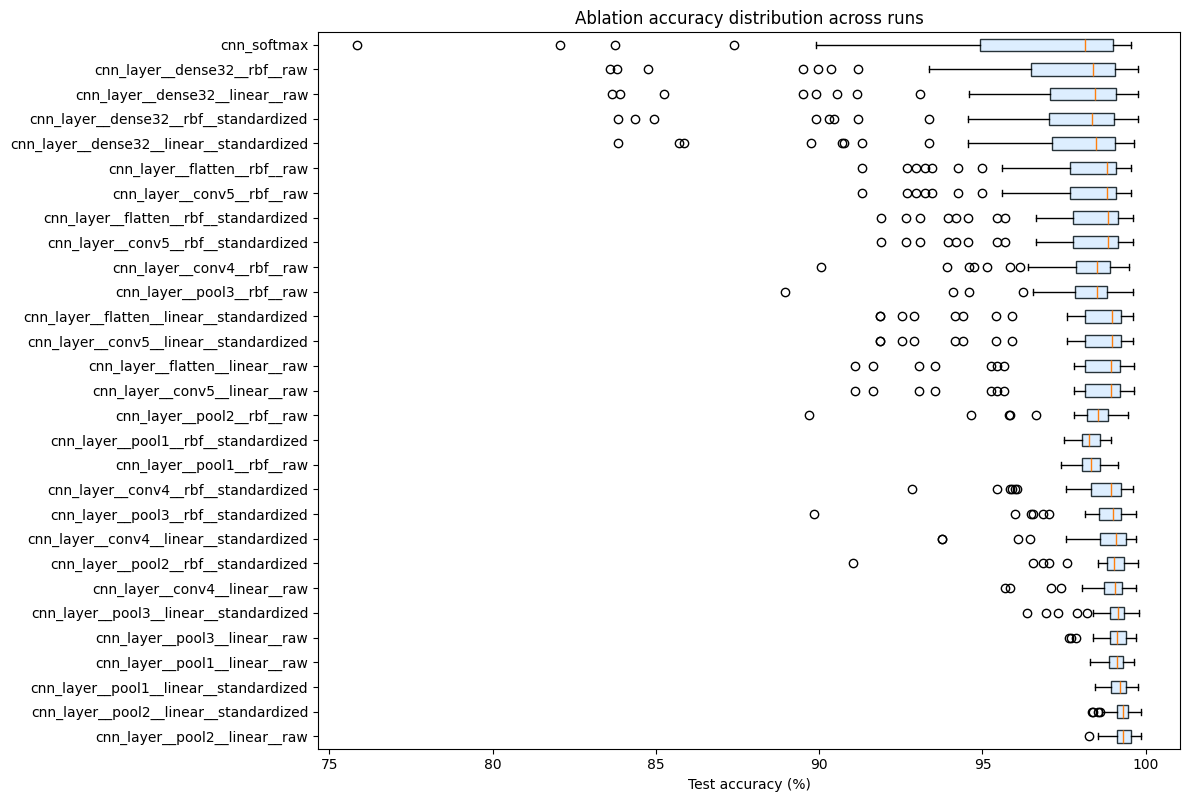

In [10]:
plt.figure(figsize=(12, max(5, 0.28 * summary.shape[0])))
order = summary["model_id"].tolist()
box_values = [results.loc[results["model_id"] == model_id, "test_accuracy_percent"].dropna().values for model_id in order]
plt.boxplot(box_values, vert=False, labels=order, patch_artist=True, boxprops={"facecolor": "#DDEEFF", "edgecolor": "#263238"})
plt.xlabel("Test accuracy (%)")
plt.ylabel("")
plt.title("Ablation accuracy distribution across runs")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "ablation_accuracy_boxplot.png", dpi=300)
plt.show()



## Paired Statistical Tests Across Runs

Tests are paired by run. The notebook saves:

- `ablation_pairwise_tests_vs_cnn.csv`: each ablation model versus the CNN softmax classifier.
- `ablation_pairwise_tests_targeted.csv`: normalization, kernel, and layer comparisons.



In [11]:
def paired_tests(frame: pd.DataFrame, model_a: str, model_b: str, label: str) -> dict:
    pivot = frame.pivot_table(index="run", columns="model_id", values="test_accuracy_percent", aggfunc="mean")
    pair = pivot[[model_a, model_b]].dropna()
    diff = pair[model_b] - pair[model_a]
    out = {
        "comparison": label,
        "model_a": model_a,
        "model_b": model_b,
        "n_pairs": int(pair.shape[0]),
        "mean_a": float(pair[model_a].mean()) if pair.shape[0] else np.nan,
        "mean_b": float(pair[model_b].mean()) if pair.shape[0] else np.nan,
        "mean_difference_b_minus_a": float(diff.mean()) if pair.shape[0] else np.nan,
        "median_difference_b_minus_a": float(diff.median()) if pair.shape[0] else np.nan,
        "cohen_dz": float(diff.mean() / diff.std(ddof=1)) if pair.shape[0] > 1 and diff.std(ddof=1) != 0 else np.nan,
        "paired_t_statistic": np.nan,
        "paired_t_pvalue": np.nan,
        "wilcoxon_statistic": np.nan,
        "wilcoxon_pvalue": np.nan,
        "shapiro_diff_statistic": np.nan,
        "shapiro_diff_pvalue": np.nan,
    }
    if pair.shape[0] >= 2:
        t_result = ttest_rel(pair[model_b], pair[model_a])
        out["paired_t_statistic"] = float(t_result.statistic)
        out["paired_t_pvalue"] = float(t_result.pvalue)
    if pair.shape[0] >= 3:
        s_result = shapiro(diff)
        out["shapiro_diff_statistic"] = float(s_result.statistic)
        out["shapiro_diff_pvalue"] = float(s_result.pvalue)
    if pair.shape[0] >= 1 and np.any(np.asarray(diff) != 0):
        try:
            w_result = wilcoxon(diff)
            out["wilcoxon_statistic"] = float(w_result.statistic)
            out["wilcoxon_pvalue"] = float(w_result.pvalue)
        except ValueError as exc:
            out["wilcoxon_pvalue"] = np.nan
            out["wilcoxon_error"] = str(exc)
    return out


model_ids = sorted(results["model_id"].unique())
vs_cnn_rows = [paired_tests(results, "cnn_softmax", model_id, f"{model_id} vs CNN softmax") for model_id in model_ids if model_id != "cnn_softmax"]
vs_cnn = pd.DataFrame(vs_cnn_rows).sort_values("mean_difference_b_minus_a", ascending=False)
vs_cnn.to_csv(OUTPUT_DIR / "ablation_pairwise_tests_vs_cnn.csv", index=False)
vs_cnn.head(20)



,comparison,model_a,model_b,n_pairs,mean_a,mean_b,mean_difference_b_minus_a,median_difference_b_minus_a,cohen_dz,paired_t_statistic,paired_t_pvalue,wilcoxon_statistic,wilcoxon_pvalue,shapiro_diff_statistic,shapiro_diff_pvalue
20,cnn_layer__pool2__linear__raw vs CNN softmax,cnn_softmax,cnn_layer__pool2__linear__raw,46,95.957609,99.267391,3.309783,0.975001,0.652225,4.423602,0.000061,0.0,2.842171e-14,0.662790,5.135070e-09
21,cnn_layer__pool2__linear__standardized vs CNN ...,cnn_softmax,cnn_layer__pool2__linear__standardized,46,95.957609,99.226087,3.268478,0.975000,0.644430,4.370739,0.000072,3.0,1.421085e-13,0.661252,4.850904e-09
17,cnn_layer__pool1__linear__standardized vs CNN ...,cnn_softmax,cnn_layer__pool1__linear__standardized,46,95.957609,99.186957,3.229348,0.899999,0.623404,4.228134,0.000114,41.0,2.829950e-10,0.678485,9.272294e-09
16,cnn_layer__pool1__linear__raw vs CNN softmax,cnn_softmax,cnn_layer__pool1__linear__raw,46,95.957609,99.068478,3.110870,0.799999,0.605162,4.104408,0.000168,87.0,4.419596e-08,0.686250,1.250678e-08
24,cnn_layer__pool3__linear__raw vs CNN softmax,cnn_softmax,cnn_layer__pool3__linear__raw,46,95.957609,99.057609,3.100000,0.899999,0.618583,4.195434,0.000126,9.0,9.379164e-13,0.655417,3.914394e-09
25,cnn_layer__pool3__linear__standardized vs CNN ...,cnn_softmax,cnn_layer__pool3__linear__standardized,46,95.957609,98.989130,3.031522,0.925001,0.621381,4.214408,0.000119,15.0,3.893774e-12,0.650524,3.275878e-09
0,cnn_layer__conv4__linear__raw vs CNN softmax,cnn_softmax,cnn_layer__conv4__linear__raw,46,95.957609,98.828261,2.870652,0.825000,0.603544,4.093436,0.000174,27.0,3.583978e-11,0.649240,3.127205e-09
23,cnn_layer__pool2__rbf__standardized vs CNN sof...,cnn_softmax,cnn_layer__pool2__rbf__standardized,46,95.957609,98.757609,2.800000,0.700002,0.550056,3.730659,0.000533,116.0,5.095428e-07,0.644209,2.609589e-09
1,cnn_layer__conv4__linear__standardized vs CNN ...,cnn_softmax,cnn_layer__conv4__linear__standardized,46,95.957609,98.654348,2.696739,0.799998,0.589975,4.001404,0.000232,13.0,2.501110e-12,0.621955,1.195169e-09
27,cnn_layer__pool3__rbf__standardized vs CNN sof...,cnn_softmax,cnn_layer__pool3__rbf__standardized,46,95.957609,98.563043,2.605435,0.550000,0.538304,3.650957,0.000678,102.0,1.647578e-07,0.634680,1.860747e-09


In [12]:
targeted_rows = []

for layer in LAYER_NAMES:
    for kernel in SVM_KERNELS:
        raw_id = safe_model_id("cnn_layer", layer, kernel, "raw")
        std_id = safe_model_id("cnn_layer", layer, kernel, "standardized")
        if raw_id in model_ids and std_id in model_ids:
            targeted_rows.append(paired_tests(results, raw_id, std_id, f"{layer} {kernel}: standardized vs raw"))

for layer in LAYER_NAMES:
    for normalization in NORMALIZATION_MODES:
        linear_id = safe_model_id("cnn_layer", layer, "linear", normalization)
        rbf_id = safe_model_id("cnn_layer", layer, "rbf", normalization)
        if linear_id in model_ids and rbf_id in model_ids:
            targeted_rows.append(paired_tests(results, linear_id, rbf_id, f"{layer} {normalization}: RBF vs linear"))

reference_layer = "dense32"
for layer in LAYER_NAMES:
    if layer == reference_layer:
        continue
    for kernel in SVM_KERNELS:
        for normalization in NORMALIZATION_MODES:
            ref_id = safe_model_id("cnn_layer", reference_layer, kernel, normalization)
            layer_id = safe_model_id("cnn_layer", layer, kernel, normalization)
            if ref_id in model_ids and layer_id in model_ids:
                targeted_rows.append(paired_tests(results, ref_id, layer_id, f"{layer} vs {reference_layer}, {kernel}, {normalization}"))

targeted = pd.DataFrame(targeted_rows)
targeted.to_csv(OUTPUT_DIR / "ablation_pairwise_tests_targeted.csv", index=False)
targeted.head(30)



,comparison,model_a,model_b,n_pairs,mean_a,mean_b,mean_difference_b_minus_a,median_difference_b_minus_a,cohen_dz,paired_t_statistic,paired_t_pvalue,wilcoxon_statistic,wilcoxon_pvalue,shapiro_diff_statistic,shapiro_diff_pvalue
0,pool1 linear: standardized vs raw,cnn_layer__pool1__linear__raw,cnn_layer__pool1__linear__standardized,46,99.068478,99.186957,0.118478,0.100,0.697926,4.733566,2.221228e-05,112.5,3.648276e-05,0.933134,1.093662e-02
1,pool1 rbf: standardized vs raw,cnn_layer__pool1__rbf__raw,cnn_layer__pool1__rbf__standardized,46,98.347826,98.279348,-0.068478,-0.150,-0.216866,-1.470855,1.482889e-01,373.5,1.035933e-01,0.959172,1.064443e-01
2,pool2 linear: standardized vs raw,cnn_layer__pool2__linear__raw,cnn_layer__pool2__linear__standardized,46,99.267391,99.226087,-0.041304,0.000,-0.389317,-2.640474,1.133993e-02,185.5,1.981979e-02,0.917835,3.168464e-03
3,pool2 rbf: standardized vs raw,cnn_layer__pool2__rbf__raw,cnn_layer__pool2__rbf__standardized,46,98.190217,98.757609,0.567391,0.475,1.042648,7.071581,7.981254e-09,12.5,1.779639e-08,0.829458,9.365530e-06
4,pool3 linear: standardized vs raw,cnn_layer__pool3__linear__raw,cnn_layer__pool3__linear__standardized,46,99.057609,98.989130,-0.068478,0.000,-0.176200,-1.195049,2.383281e-01,426.0,9.534317e-01,0.649843,3.196211e-09
5,pool3 rbf: standardized vs raw,cnn_layer__pool3__rbf__raw,cnn_layer__pool3__rbf__standardized,46,97.981522,98.563043,0.581522,0.425,1.144043,7.759275,7.740987e-10,4.0,1.989520e-13,0.862343,6.541038e-05
6,conv4 linear: standardized vs raw,cnn_layer__conv4__linear__raw,cnn_layer__conv4__linear__standardized,46,98.828261,98.654348,-0.173913,0.025,-0.323150,-2.191712,3.361621e-02,382.5,3.879300e-01,0.726756,6.464934e-08
7,conv4 rbf: standardized vs raw,cnn_layer__conv4__rbf__raw,cnn_layer__conv4__rbf__standardized,46,97.928261,98.438043,0.509783,0.375,0.915823,6.211415,1.514834e-07,16.0,1.485080e-08,0.790661,1.211661e-06
8,conv5 linear: standardized vs raw,cnn_layer__conv5__linear__raw,cnn_layer__conv5__linear__standardized,46,98.142391,97.995652,-0.146739,-0.050,-0.348196,-2.361582,2.258570e-02,218.5,1.654885e-02,0.801233,2.067175e-06
9,conv5 rbf: standardized vs raw,cnn_layer__conv5__rbf__raw,cnn_layer__conv5__rbf__standardized,46,97.779348,97.925000,0.145652,0.100,0.451932,3.065150,3.671004e-03,206.0,1.253346e-03,0.936368,1.435759e-02


## Optional: Statistical Tests on the Article's Existing 46-Run Robustness CSV

This does not replace the new ablation experiment. It simply analyzes the existing robustness table if the CSV exists.



In [13]:
existing_candidates = [
    NOTEBOOK_DIR / "image_latex" / "result_robustness_runs.csv",
    NOTEBOOK_DIR / "result_robustness_runs.csv",
    NOTEBOOK_DIR.parent / "image_latex" / "result_robustness_runs.csv",
]
existing_path = next((path for path in existing_candidates if path.exists()), existing_candidates[0])
if existing_path.exists():
    existing = pd.read_csv(existing_path)
    existing_long = existing.rename(
        columns={
            "cnn_test_accuracy_percent": "CNN softmax",
            "cnn_svm_linear_accuracy_percent": "CNN-SVM linear",
            "cnn_svm_rbf_accuracy_percent": "CNN-SVM RBF",
        }
    )
    existing_long = existing_long.melt(id_vars=["run"], var_name="model_id", value_name="test_accuracy_percent")
    existing_tests = pd.DataFrame(
        [
            paired_tests(existing_long, "CNN softmax", "CNN-SVM linear", "Existing 46 runs: CNN-SVM linear vs CNN softmax"),
            paired_tests(existing_long, "CNN softmax", "CNN-SVM RBF", "Existing 46 runs: CNN-SVM RBF vs CNN softmax"),
            paired_tests(existing_long, "CNN-SVM RBF", "CNN-SVM linear", "Existing 46 runs: CNN-SVM linear vs CNN-SVM RBF"),
        ]
    )
    existing_tests.to_csv(OUTPUT_DIR / "existing_robustness_pairwise_tests.csv", index=False)
    print(existing_tests.to_string(index=False))
else:
    print("Existing robustness CSV not found:", existing_path)



Existing robustness CSV not found: C:\Users\lamar\Desktop\Vinicius\EAAI Tests\image_latex\result_robustness_runs.csv


## Output Manifest



In [14]:
manifest_rows = []
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        manifest_rows.append(
            {
                "relative_path": str(path.relative_to(OUTPUT_DIR)),
                "bytes": path.stat().st_size,
                "modified_time": pd.Timestamp.fromtimestamp(path.stat().st_mtime).isoformat(),
            }
        )
manifest = pd.DataFrame(manifest_rows)
manifest.to_csv(OUTPUT_DIR / "ablation_output_manifest.csv", index=False)
manifest


,relative_path,bytes,modified_time
0,ablation_accuracy_long.csv,177312,2026-05-01T08:06:47.670673
1,ablation_metadata.json,936,2026-04-30T18:00:42.542758
2,ablation_pairwise_tests_targeted.csv,16007,2026-05-01T08:06:48.589588
3,ablation_pairwise_tests_vs_cnn.csv,8573,2026-05-01T08:06:48.395728
4,ablation_summary.csv,5574,2026-05-01T08:06:47.766199
...,...,...,...
2715,predictions\run_046__cnn_layer__pool3__linear_...,10028,2026-05-01T08:06:18.105651
2716,predictions\run_046__cnn_layer__pool3__linear_...,10028,2026-05-01T08:06:18.900219
2717,predictions\run_046__cnn_layer__pool3__rbf__ra...,10028,2026-05-01T08:06:24.569546
2718,predictions\run_046__cnn_layer__pool3__rbf__st...,10028,2026-05-01T08:06:28.789152
